In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [22]:
# ==================================================
# 1. Data Fetching (S&P 500 + Bond ETF)
# ==================================================
print("Downloading data...")
stock_ticker = '^GSPC'      # S&P 500 index
bond_ticker = 'TLT'         # iShares 20+ Year Treasury Bond ETF
start_date = '2010-01-01'
end_date = '2024-12-31'

# Download both
data = yf.download([stock_ticker, bond_ticker], start=start_date, end=end_date)

# Extract adjusted close (or close for index)
if isinstance(data.columns, pd.MultiIndex):
    # MultiIndex case: (Price, Ticker)
    stock_prices = data[('Adj Close', stock_ticker)] if ('Adj Close', stock_ticker) in data else data[('Close', stock_ticker)]
    bond_prices = data[('Adj Close', bond_ticker)] if ('Adj Close', bond_ticker) in data else data[('Close', bond_ticker)]
else:
    # Single-level columns
    stock_prices = data['Adj Close'] if 'Adj Close' in data else data['Close']
    bond_prices = data['Adj Close'] if 'Adj Close' in data else data['Close']

# Drop NaN and align
stock_prices = stock_prices.dropna()
bond_prices = bond_prices.dropna()
common_index = stock_prices.index.intersection(bond_prices.index)
stock_prices = stock_prices.loc[common_index]
bond_prices = bond_prices.loc[common_index]

# Daily returns
stock_returns = stock_prices.pct_change().dropna()
bond_returns = bond_prices.pct_change().dropna()

# Align returns
common_returns_index = stock_returns.index.intersection(bond_returns.index)
stock_returns = stock_returns.loc[common_returns_index]
bond_returns = bond_returns.loc[common_returns_index]
prices = stock_prices.loc[common_returns_index]   # for plotting

[*********************100%***********************]  2 of 2 completed


In [23]:
# ==================================================
# 2. Rolling Shannon Entropy Function
# ==================================================
def rolling_shannon_entropy(series, window, n_bins=10):
    """
    Compute rolling Shannon entropy with expanding bins (no look‑ahead).
    Returns a Series aligned with the end of each window.
    """
    entropies = []
    for i in range(window, len(series) + 1):
        window_data = series.iloc[i - window : i]
        # Use expanding window up to current index to define bins (no look‑ahead)
        hist_data = series.iloc[:i]
        bins = np.percentile(hist_data, np.linspace(0, 100, n_bins + 1))
        if len(np.unique(bins)) < 2:
            bins = np.array([-np.inf, np.inf])
        else:
            bins = np.unique(bins)
        digitized = np.digitize(window_data, bins, right=False)
        counts = np.bincount(digitized, minlength=len(bins))[1:]
        probs = counts / np.sum(counts)
        entropy = -np.sum(probs * np.log2(probs + 1e-12))
        entropies.append(entropy)
    return pd.Series(entropies, index=series.index[window - 1:])

In [24]:
# ==================================================
# 3. Compute Rolling Entropy
# ==================================================
window_size = 60          # 60 trading days (~3 months)
n_bins = 10

entropy = rolling_shannon_entropy(stock_returns, window_size, n_bins=n_bins)
print(f"Entropy computed for {len(entropy)} days.")

Entropy computed for 3713 days.


In [40]:
# ==================================================
# 4. Online Regime Detection with Rolling Change Points
# ==================================================
def online_pelt_regime(entropy_series, lookback=500, pen=10):
    """
    Online regime detection using PELT on a rolling window of entropy values.
    At each day t (after initial warm‑up), we take the last `lookback` entropy values,
    detect change points, and label the current regime based on the mean entropy
    of the last segment relative to the overall mean of the window.

    Returns a Series of regime labels (0 = low entropy, 1 = high entropy)
    aligned with the dates of entropy_series.
    """
    import ruptures as rpt

    regimes = pd.Series(index=entropy_series.index, dtype=int)
    # Need at least lookback points to start
    for i in range(lookback, len(entropy_series)):
        # Sliding window of entropy values
        window_entropy = entropy_series.iloc[i - lookback : i]
        # Convert to numpy array for ruptures
        values = window_entropy.values.reshape(-1, 1)
        # Fit PELT
        algo = rpt.Pelt(model='rbf').fit(values)
        # Predict change points (pen is a hyperparameter)
        change_points = algo.predict(pen=pen)
        # Get segment indices (starting from 0)
        segment_indices = [0] + change_points[:-1]  # exclude last point which is len(window)
        # Determine mean entropy for each segment
        segment_means = []
        for start, end in zip(segment_indices, change_points):
            segment = window_entropy.iloc[start:end]
            segment_means.append(segment.mean())
        # Current point belongs to last segment (index change_points[-2] to change_points[-1])
        last_segment_mean = segment_means[-1]
        # Overall mean of the window (or median, etc.)
        overall_mean = window_entropy.mean()
        # Label: 1 if last segment mean > overall_mean (high entropy), else 0
        regime_label = 1 if last_segment_mean > overall_mean else 0
        regimes.iloc[i] = regime_label

    # Fill initial part (first lookback days) with 0 (or maybe forward fill later)
    regimes.iloc[:lookback] = 0
    return regimes

# Parameters for online detection
lookback_days = 500        # 2 years approx (500 trading days)
pelt_penalty = 5           # penalty for PELT (tune for your data)

print(f"Running online change-point detection (lookback={lookback_days}, penalty={pelt_penalty})...")
regime = online_pelt_regime(entropy, lookback=lookback_days, pen=pelt_penalty)

Running online change-point detection (lookback=500, penalty=5)...


In [41]:
# ==================================================
# 5. Strategy Definition (Switch to Bonds on High Entropy)
# ==================================================
# Create a DataFrame with daily returns and regime
strategy = pd.DataFrame(index=stock_returns.index)
strategy['stock_returns'] = stock_returns
strategy['bond_returns'] = bond_returns
# Forward-fill regime (only available after lookback days)
strategy['regime'] = regime.reindex(strategy.index, method='ffill').fillna(0).astype(int)

# Portfolio returns: use stocks when regime=0 (low entropy), bonds when regime=1 (high entropy)
strategy['portfolio_returns'] = np.where(strategy['regime'] == 0,
                                         strategy['stock_returns'],
                                         strategy['bond_returns'])
# Shift by one day to avoid look‑ahead (signal known at end of day, used next day)
strategy['strategy_returns'] = strategy['portfolio_returns'].shift(1)

# Benchmark: buy‑and‑hold stocks
strategy['benchmark_returns'] = strategy['stock_returns']

# Cumulative returns
strategy['cum_strategy'] = (1 + strategy['strategy_returns']).cumprod()
strategy['cum_benchmark'] = (1 + strategy['benchmark_returns']).cumprod()

In [42]:
# ==================================================
# 6. Performance Metrics
# ==================================================
def compute_metrics(returns_series):
    total_return = (1 + returns_series).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(returns_series)) - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    return {
        'Total Return': total_return,
        'Annualized Return': ann_return,
        'Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe
    }

metrics_strategy = compute_metrics(strategy['strategy_returns'].dropna())
metrics_benchmark = compute_metrics(strategy['benchmark_returns'].dropna())


print("\nStrategy Performance (Bonds on High Entropy):")
for k, v in metrics_strategy.items():
    print(f"{k}: {v:.4f}")

print("\nBenchmark (100% Stocks) Performance:")
for k, v in metrics_benchmark.items():
    print(f"{k}: {v:.4f}")


Strategy Performance (Bonds on High Entropy):
Total Return: 1.4750
Annualized Return: 0.0624
Annualized Volatility: 0.1630
Sharpe Ratio: 0.3830

Benchmark (100% Stocks) Performance:
Total Return: 4.2136
Annualized Return: 0.1166
Annualized Volatility: 0.1724
Sharpe Ratio: 0.6767


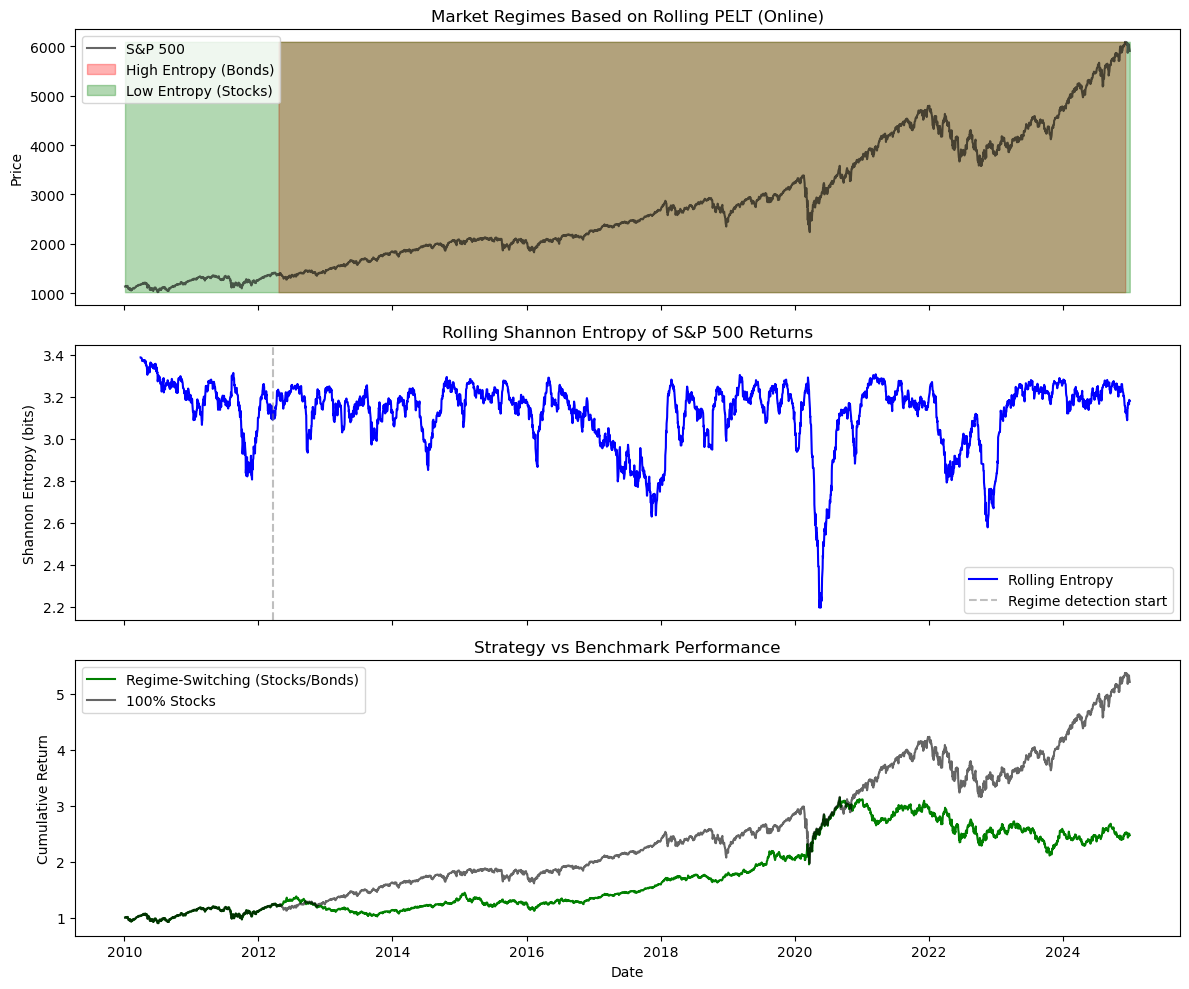

In [43]:
# ==================================================
# 7. Plotting
# ==================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Top: Price with regime shading
ax1 = axes[0]
ax1.plot(prices, label='S&P 500', color='black', alpha=0.6)
regime_high = strategy[strategy['regime'] == 1].index
regime_low = strategy[strategy['regime'] == 0].index
ax1.fill_between(regime_high, prices.min(), prices.max(), color='red', alpha=0.3, label='High Entropy (Bonds)')
ax1.fill_between(regime_low, prices.min(), prices.max(), color='green', alpha=0.3, label='Low Entropy (Stocks)')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')
ax1.set_title('Market Regimes Based on Rolling PELT (Online)')

# Middle: Rolling entropy (only shown after lookback period)
ax2 = axes[1]
ax2.plot(entropy, color='blue', label='Rolling Entropy')
# Mark the point where regime detection starts
ax2.axvline(entropy.index[lookback_days], color='gray', linestyle='--', alpha=0.5, label='Regime detection start')
ax2.set_ylabel('Shannon Entropy (bits)')
ax2.legend()
ax2.set_title('Rolling Shannon Entropy of S&P 500 Returns')

# Bottom: Cumulative returns
ax3 = axes[2]
ax3.plot(strategy['cum_strategy'], label='Regime‑Switching (Stocks/Bonds)', color='green')
ax3.plot(strategy['cum_benchmark'], label='100% Stocks', color='black', alpha=0.6)
ax3.set_ylabel('Cumulative Return')
ax3.set_xlabel('Date')
ax3.legend()
ax3.set_title('Strategy vs Benchmark Performance')

plt.tight_layout()
plt.show()

In [12]:
pip install ruptures

Note: you may need to restart the kernel to use updated packages.
